# **1. Importación de librerías y configuración**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual profesional para gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 100})

import warnings
warnings.filterwarnings('ignore')

# **2. Carga de datos**

In [4]:
df = pd.read_csv("../data/raw/credit_card_transactions.csv")
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 25 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   transaction_id             500000 non-null  str    
 1   customer_id                500000 non-null  str    
 2   transaction_time           500000 non-null  str    
 3   transaction_amount         500000 non-null  float64
 4   merchant_category          500000 non-null  str    
 5   transaction_type           500000 non-null  str    
 6   payment_method             500000 non-null  str    
 7   city                       500000 non-null  str    
 8   country                    500000 non-null  str    
 9   device_type                500000 non-null  str    
 10  operating_system           500000 non-null  str    
 11  browser                    500000 non-null  str    
 12  card_type                  500000 non-null  str    
 13  card_present               500000 non-nu

None

# **3. Magnitud del desbalanceo**

Transacciones Totales: 500000
Legítimas (0): 488320 (97.66%)
Fraudulentas (1): 11680 (2.34%)


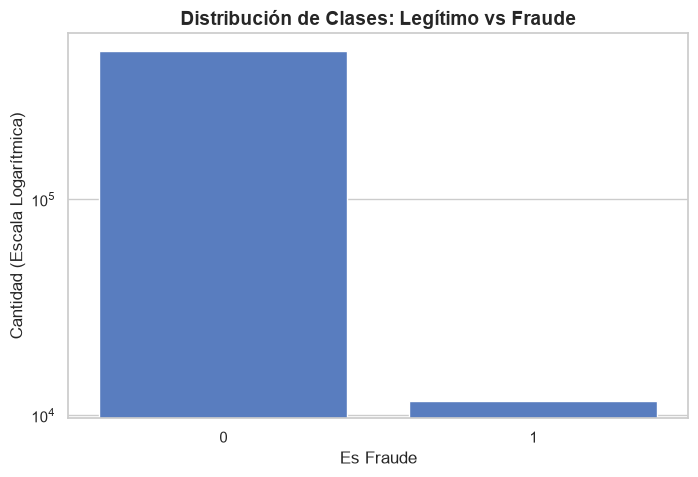

In [5]:
# Verificamos la proporción exacta de fraude
fraud_counts = df['is_fraud'].value_counts()
fraud_rates = df['is_fraud'].value_counts(normalize=True) * 100

print("Transacciones Totales:", len(df))
print(f"Legítimas (0): {fraud_counts[0]} ({fraud_rates[0]:.2f}%)")
print(f"Fraudulentas (1): {fraud_counts[1]} ({fraud_rates[1]:.2f}%)")

# Visualización del desbalance
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='is_fraud')
plt.title('Distribución de Clases: Legítimo vs Fraude', fontsize=14, fontweight='bold')
plt.yscale('log') # Escala logarítmica crucial para ver la barra de fraude
plt.ylabel('Cantidad (Escala Logarítmica)')
plt.xlabel('Es Fraude')
plt.show()

# **4. Análisis de Montos (El impacto al negocio)**

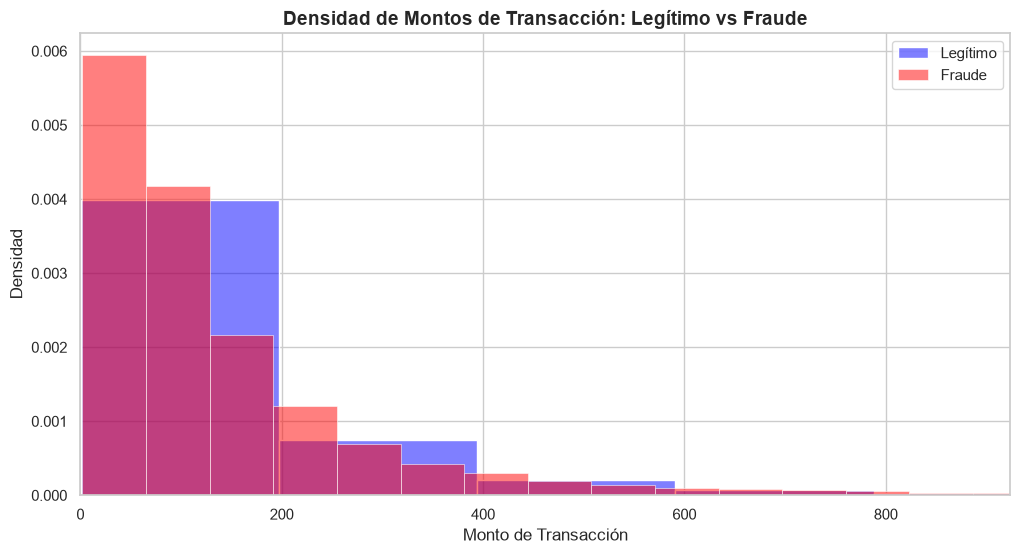

In [6]:
# ¿Cómo se distribuyen los montos de transacciones fraudulentas vs legítimas?
plt.figure(figsize=(12, 6))
sns.histplot(data=df[df['is_fraud'] == 0], x='transaction_amount', bins=50, color='blue', alpha=0.5, label='Legítimo', stat='density')
sns.histplot(data=df[df['is_fraud'] == 1], x='transaction_amount', bins=50, color='red', alpha=0.5, label='Fraude', stat='density')

plt.title('Densidad de Montos de Transacción: Legítimo vs Fraude', fontsize=14, fontweight='bold')
plt.xlim(0, df['transaction_amount'].quantile(0.99)) # Cortamos el 1% de outliers para ver mejor
plt.xlabel('Monto de Transacción')
plt.ylabel('Densidad')
plt.legend()
plt.show()

# **5. Análisis de Canales y Contexto (Card Present & Internacional)**

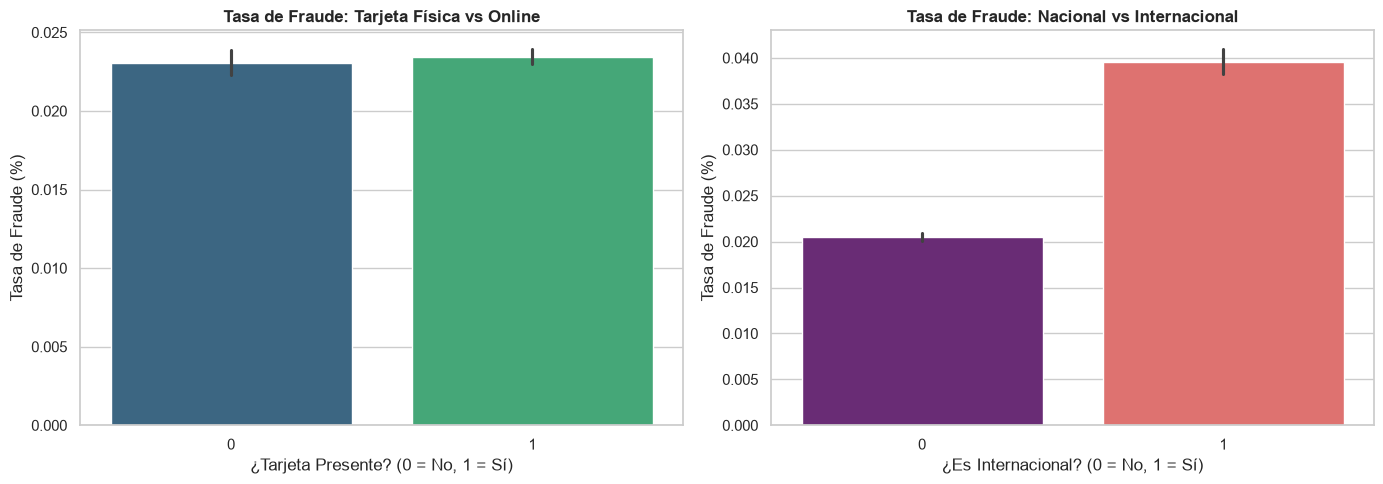

In [7]:
# Tasa de fraude por presencia de tarjeta y tipo de transacción (Nacional vs Internacional)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Tarjeta Presente vs No Presente
# sns.barplot con y='is_fraud' calcula automáticamente la media (la tasa de fraude)
sns.barplot(data=df, x='card_present', y='is_fraud', ax=axes[0], palette='viridis')
axes[0].set_title('Tasa de Fraude: Tarjeta Física vs Online', fontweight='bold')
axes[0].set_ylabel('Tasa de Fraude (%)')
axes[0].set_xlabel('¿Tarjeta Presente? (0 = No, 1 = Sí)')

# Gráfico 2: Transacción Nacional vs Internacional
sns.barplot(data=df, x='international_transaction', y='is_fraud', ax=axes[1], palette='magma')
axes[1].set_title('Tasa de Fraude: Nacional vs Internacional', fontweight='bold')
axes[1].set_ylabel('Tasa de Fraude (%)')
axes[1].set_xlabel('¿Es Internacional? (0 = No, 1 = Sí)')

plt.tight_layout()
plt.show()

# **6. Análisis de Comportamiento (Distancia y Tiempo)**

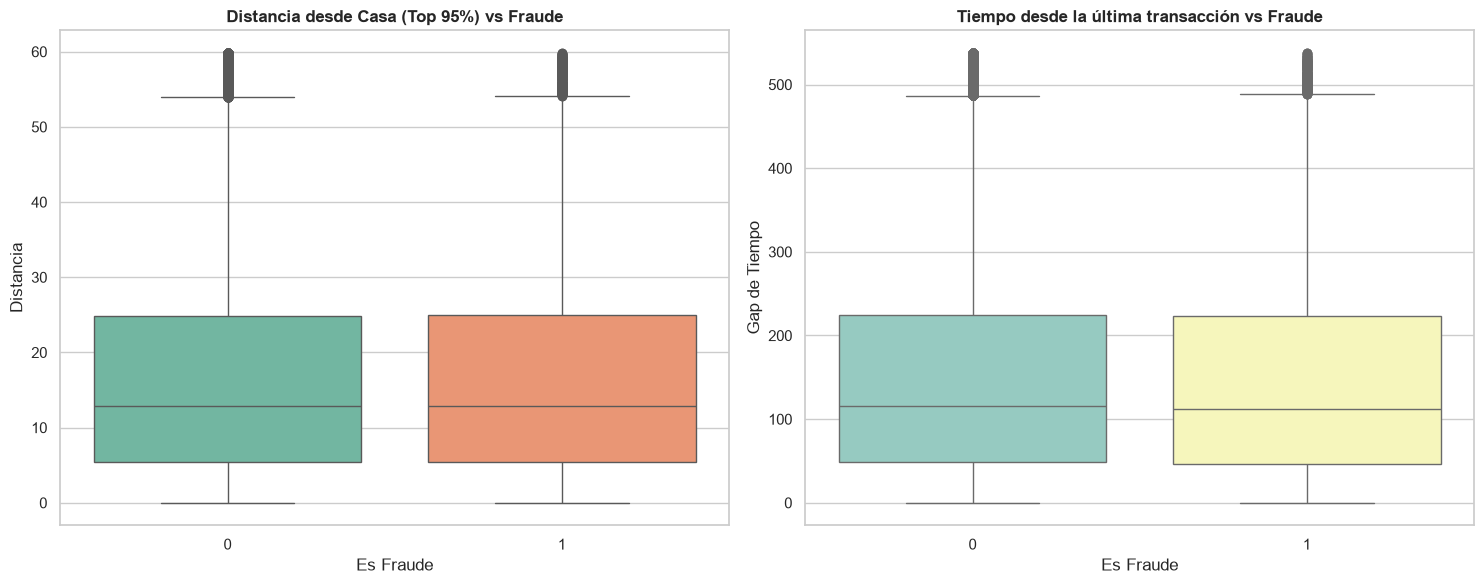

In [8]:
# Limitamos los datos a un percentil razonable para evitar que los outliers arruinen la visualización
dist_threshold = df['distance_from_home'].quantile(0.95)
gap_threshold = df['previous_transaction_gap'].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot para la distancia desde casa
sns.boxplot(data=df[df['distance_from_home'] < dist_threshold], 
            x='is_fraud', y='distance_from_home', ax=axes[0], palette='Set2')
axes[0].set_title('Distancia desde Casa (Top 95%) vs Fraude', fontweight='bold')
axes[0].set_xlabel('Es Fraude')
axes[0].set_ylabel('Distancia')

# Boxplot para el tiempo desde la última transacción
sns.boxplot(data=df[df['previous_transaction_gap'] < gap_threshold], 
            x='is_fraud', y='previous_transaction_gap', ax=axes[1], palette='Set3')
axes[1].set_title('Tiempo desde la última transacción vs Fraude', fontweight='bold')
axes[1].set_xlabel('Es Fraude')
axes[1].set_ylabel('Gap de Tiempo')

plt.tight_layout()
plt.show()

# **7. Análisis de Riesgo por Categoría de Comercio**

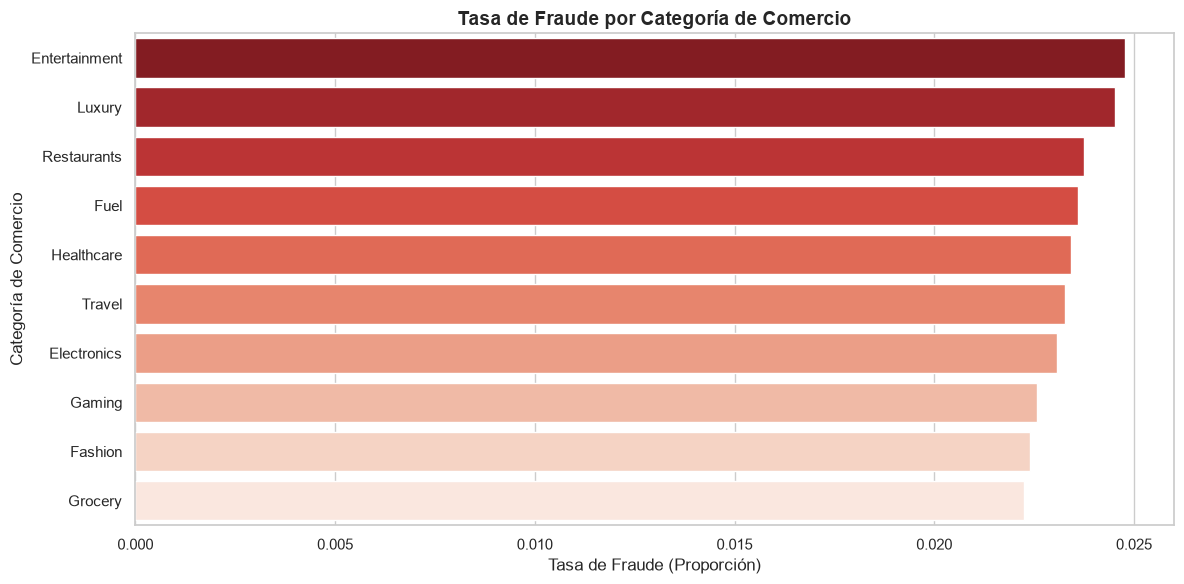

In [9]:
# Calculamos el volumen de transacciones y la tasa de fraude por categoría
merchant_stats = df.groupby('merchant_category').agg(
    total_tx=('is_fraud', 'count'),
    fraud_rate=('is_fraud', 'mean')
).reset_index()

# Ordenamos por las categorías con mayor tasa de fraude
merchant_stats = merchant_stats.sort_values(by='fraud_rate', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=merchant_stats, x='fraud_rate', y='merchant_category', 
            palette='Reds_r',order=merchant_stats['merchant_category'])
plt.title('Tasa de Fraude por Categoría de Comercio', fontsize=14, fontweight='bold')
plt.xlabel('Tasa de Fraude (Proporción)')
plt.ylabel('Categoría de Comercio')
plt.tight_layout()
plt.show()

# **8. Mapa de Correlación Lineal Inicial**

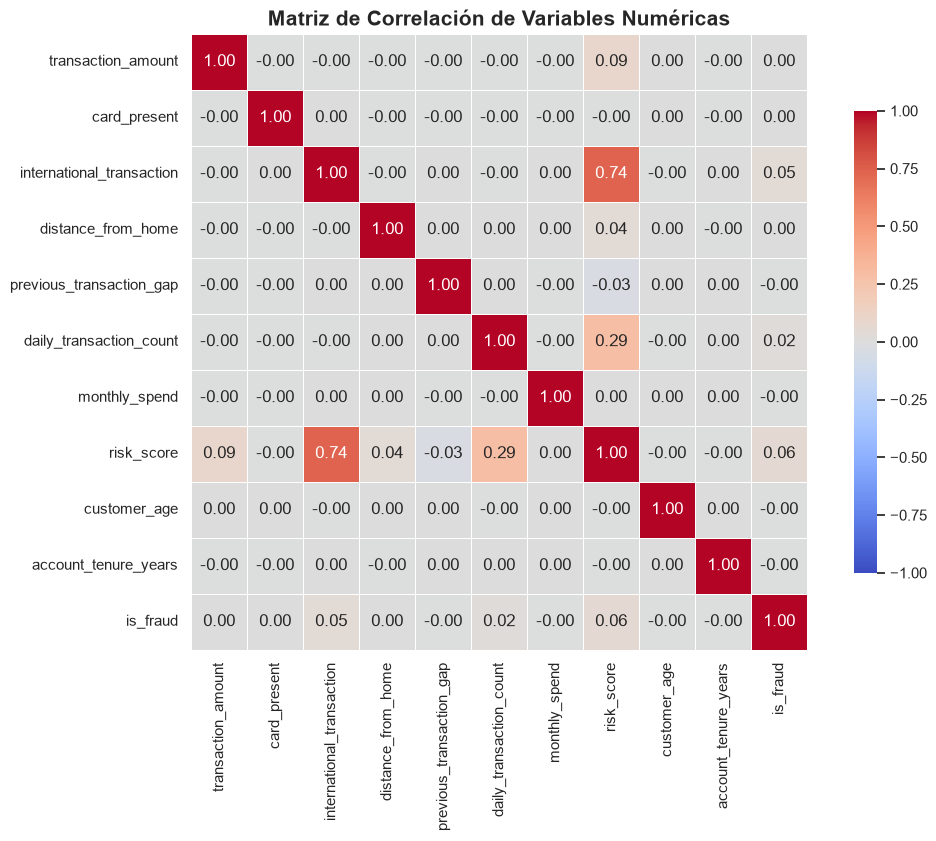

In [10]:
# Seleccionamos solo las variables numéricas (excluyendo IDs y fechas)
numeric_cols = df.select_dtypes(include=['float16', 'float32', 'float64', 'int8', 'int16', 'int32', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
# Usamos un heatmap divergente para ver correlaciones positivas y negativas
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=.5, cbar_kws={"shrink": .75})
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=15, fontweight='bold')
plt.show()

# **9. Conclusion EDA**

1. Casi nula correlación lineal con el Fraude *(is_fraud)*: Variables como *transaction_amount* (0.0032), *distance_from_home* (0.0032) o *international_transaction* (0.045) tienen una correlación lineal cercana a cero con la variable objetivo. Esto significa que el fraude no es lineal. Un estafador no se delata simplemente gastando más dinero o yendo más lejos; el fraude ocurre en intersecciones complejas (ej. una transacción internacional + monto inusual + poco tiempo desde la última compra).

2. Fuerte multicolinealidad detectada: Existe una correlación de 0.735 entre *risk_scor*e e *international_transaction*. Esto nos indica que el sistema "legacy" o las reglas de negocio que actualmente generan ese *risk_score* están fuertemente sesgadas a penalizar las transacciones internacionales.

Dado que las relaciones lineales son tan débiles, un modelo tradicional como la Regresión Logística fracasaría aquí. Es por esto que tu elección de usar algoritmos basados en árboles (XGBoost, LightGBM, Random Forest) es la correcta, ya que son excelentes encontrando esos patrones no lineales.